In [46]:
import pandas as pd
df_feux = pd.read_csv("incendies.csv", sep=",", encoding="utf-8", header=2)
df_feux['date'] = pd.to_datetime(df_feux['Date de première alerte']).dt.strftime('%Y-%m-%d')

In [65]:
df_feux.head(5)

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),...,Précision des surfaces,Type de peuplement,Nature,Décès ou bâtiments touchés,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits,Précision de la donnée,date,fwi_associe
0,2025,7950,11,11311,Ribaute,8/5/2025 16:16,"111,330,000.00","56,120,000.00","51,160,000.00",0,...,Mesurées,NaN,Malveillance,Oui,1.0,71.0,74.0,NaN,2025-08-05,86.9
1,2025,7867,11,11262,Narbonne,7/7/2025 14:45,"15,512,500.00","8,834,900.00","6,677,600.00",0,...,Mesurées,NaN,Involontaire (particulier),Oui,0.0,0.0,5.0,NaN,2025-07-07,22.3
2,2025,5932,13,13071,Les Pennes-Mirabeau,7/8/2025 12:49,"6,162,500.00","5,530,100.00",0,0,...,Mesurées,1.0,Accidentelle,Oui,0.0,80.0,10.0,NaN,2025-07-08,84.0
3,2025,17277,30,30176,Montdardier,7/8/2025 13:46,"4,116,800.00","116,800.00","4,000,000.00",0,...,Mesurées,NaN,Accidentelle,Non,NaN,NaN,NaN,NaN,2025-07-08,NaN
4,2025,7857,11,11122,Douzens,7/5/2025 13:33,"3,647,900.00","2,196,300.00","1,451,600.00",0,...,Mesurées,4.0,Accidentelle,Non,NaN,NaN,NaN,NaN,2025-07-05,58.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2025,11494,2A,2A282,Soccia,9/24/2025 15:03,1.00,1.00,0,0,...,Estimées,NaN,Naturelle,Non,NaN,NaN,NaN,NaN,2025-09-24,NaN
2532,2025,9997,83,83094,Le Plan-de-la-Tour,10/9/2025 20:28,1.00,0,1.00,0,...,Estimées,5.0,NaN,Non,NaN,NaN,NaN,NaN,2025-10-09,NaN
2533,2025,11767,2A,2A041,Bonifacio,11/16/2025 10:00,1.00,0,1.00,0,...,Estimées,NaN,NaN,Non,NaN,NaN,NaN,NaN,2025-11-16,NaN
2534,2025,13825,34,34300,Servian,12/14/2025 18:36,1.00,0,1.00,0,...,Estimées,NaN,NaN,Non,NaN,NaN,NaN,NaN,2025-12-14,NaN


In [36]:
import requests
API_URL = "http://127.0.0.1:8000/cameras"

try:
    response = requests.get(API_URL)
    response.raise_for_status()
    cameras_json = response.json()

    df_cameras = pd.DataFrame(cameras_json)
    

except requests.exceptions.RequestException as e:
    print(f"Erreur lors de la connexion à l'API : {e}")

In [37]:
df_cameras

,id,name,organization_id,lat,lon,fwi,fwi_class,last_refresh_at
0,1,camera-001,2,48.8487,3.0244,None,None,None
1,2,camera-002,2,48.5399,2.2086,None,None,None
2,3,camera-003,2,48.6695,2.9506,None,None,None
3,4,camera-004,2,44.5062,4.2711,None,None,None
4,6,camera-006,1,44.5062,4.2711,None,None,None
...,...,...,...,...,...,...,...,...
109,136,camera-136,21,48.3902,2.1986,None,None,None
110,137,camera-137,21,48.3902,2.1986,None,None,None
111,138,camera-138,4,45.6183,6.0890,None,None,None
112,141,camera-141,22,48.8711,1.6329,None,None,None


In [33]:
import requests
import pandas as pd

DATE = "2025-08-05"

API_URL = f"http://127.0.0.1:8000/scores/{DATE}"

try:
    response = requests.get(API_URL)
    response.raise_for_status()
    scores_json = response.json()
    df = pd.DataFrame(scores_json)


except requests.exceptions.RequestException as e:
    print(f"Erreur lors de la connexion à l'API : {e}")

In [34]:
df

,camera_id,date,fwi,fwi_class,fetched_at
0,1,2025-08-05,2.270,very_low,2026-06-30T08:21:26.076055Z
1,2,2025-08-05,1.755,very_low,2026-06-30T08:21:26.076055Z
2,3,2025-08-05,3.256,very_low,2026-06-30T08:21:26.076055Z
3,4,2025-08-05,51.833,extreme,2026-06-30T08:21:26.076055Z
4,6,2025-08-05,51.833,extreme,2026-06-30T08:21:26.076055Z
...,...,...,...,...,...
109,136,2025-08-05,3.456,very_low,2026-06-30T08:21:26.076055Z
110,137,2025-08-05,3.456,very_low,2026-06-30T08:21:26.076055Z
111,138,2025-08-05,4.059,very_low,2026-06-30T08:21:26.076055Z
112,141,2025-08-05,8.023,low,2026-06-30T08:21:26.076055Z


In [40]:
import geopandas as gpd
from shapely.geometry import Point


geometrie = [Point(xy) for xy in zip(df_cameras['lon'], df_cameras['lat'])]

gdf_cameras = gpd.GeoDataFrame(df_cameras, geometry=geometrie, crs="EPSG:4326")

url_contours_deps = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
gdf_departements = gpd.read_file(url_contours_deps)

gdf_enrichi = gpd.sjoin(gdf_cameras, gdf_departements, how="left", predicate="within")

df_final = pd.DataFrame(gdf_enrichi).rename(columns={
    'code': 'code_departement',
    'nom': 'nom_departement'
})


df_cameras = df_final.drop(columns=['geometry', 'index_right'])


In [41]:
df_cameras

,id,name,organization_id,lat,lon,fwi,fwi_class,last_refresh_at,code_departement,nom_departement
0,1,camera-001,2,48.8487,3.0244,None,None,None,77,Seine-et-Marne
1,2,camera-002,2,48.5399,2.2086,None,None,None,91,Essonne
2,3,camera-003,2,48.6695,2.9506,None,None,None,77,Seine-et-Marne
3,4,camera-004,2,44.5062,4.2711,None,None,None,07,Ardèche
4,6,camera-006,1,44.5062,4.2711,None,None,None,07,Ardèche
...,...,...,...,...,...,...,...,...,...,...
109,136,camera-136,21,48.3902,2.1986,None,None,None,91,Essonne
110,137,camera-137,21,48.3902,2.1986,None,None,None,91,Essonne
111,138,camera-138,4,45.6183,6.0890,None,None,None,73,Savoie
112,141,camera-141,22,48.8711,1.6329,None,None,None,78,Yvelines


In [64]:
df_feux['date'] = pd.to_datetime(df_feux['date']).dt.strftime('%Y-%m-%d')
df_feux['Département'] = df_feux['Département'].astype(str)


liste_fwi_trouves = []

for idx, ligne_feu in df_feux.iterrows():
    date_feu = ligne_feu['date']
    dep_feu = ligne_feu['Département']
    

    cams_du_dep = df_cameras[df_cameras['code_departement'] == dep_feu]['id'].tolist()
    fwi_cam_scores = []
    for cam_id in cams_du_dep:
        try:
            url_cible = f"http://127.0.0.1:8000/scores/{date_feu}?camera_id={cam_id}"
            response = requests.get(url_cible)
            response.raise_for_status()
            
            donnees_score = response.json()
            if donnees_score:
                fwi_cam_scores.append(donnees_score[0]['fwi'])
        except Exception as e:
            print(f"Erreur pour la caméra {cam_id} à la date {date_feu} : {e}")


    if fwi_cam_scores:
        fwi_moyen_du_jour = sum(fwi_cam_scores) / len(fwi_cam_scores)
        liste_fwi_trouves.append(round(fwi_moyen_du_jour, 1))
    else:
        liste_fwi_trouves.append(None)

df_feux['fwi_associe'] = liste_fwi_trouves

In [66]:
df_feux

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),...,Précision des surfaces,Type de peuplement,Nature,Décès ou bâtiments touchés,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits,Précision de la donnée,date,fwi_associe
0,2025,7950,11,11311,Ribaute,8/5/2025 16:16,"111,330,000.00","56,120,000.00","51,160,000.00",0,...,Mesurées,NaN,Malveillance,Oui,1.0,71.0,74.0,NaN,2025-08-05,86.9
1,2025,7867,11,11262,Narbonne,7/7/2025 14:45,"15,512,500.00","8,834,900.00","6,677,600.00",0,...,Mesurées,NaN,Involontaire (particulier),Oui,0.0,0.0,5.0,NaN,2025-07-07,22.3
2,2025,5932,13,13071,Les Pennes-Mirabeau,7/8/2025 12:49,"6,162,500.00","5,530,100.00",0,0,...,Mesurées,1.0,Accidentelle,Oui,0.0,80.0,10.0,NaN,2025-07-08,84.0
3,2025,17277,30,30176,Montdardier,7/8/2025 13:46,"4,116,800.00","116,800.00","4,000,000.00",0,...,Mesurées,NaN,Accidentelle,Non,NaN,NaN,NaN,NaN,2025-07-08,NaN
4,2025,7857,11,11122,Douzens,7/5/2025 13:33,"3,647,900.00","2,196,300.00","1,451,600.00",0,...,Mesurées,4.0,Accidentelle,Non,NaN,NaN,NaN,NaN,2025-07-05,58.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2531,2025,11494,2A,2A282,Soccia,9/24/2025 15:03,1.00,1.00,0,0,...,Estimées,NaN,Naturelle,Non,NaN,NaN,NaN,NaN,2025-09-24,NaN
2532,2025,9997,83,83094,Le Plan-de-la-Tour,10/9/2025 20:28,1.00,0,1.00,0,...,Estimées,5.0,NaN,Non,NaN,NaN,NaN,NaN,2025-10-09,NaN
2533,2025,11767,2A,2A041,Bonifacio,11/16/2025 10:00,1.00,0,1.00,0,...,Estimées,NaN,NaN,Non,NaN,NaN,NaN,NaN,2025-11-16,NaN
2534,2025,13825,34,34300,Servian,12/14/2025 18:36,1.00,0,1.00,0,...,Estimées,NaN,NaN,Non,NaN,NaN,NaN,NaN,2025-12-14,NaN


In [69]:
df_feux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2536 entries, 0 to 2535
Data columns (total 26 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Année                                       2536 non-null   int64  
 1   Numéro                                      2536 non-null   int64  
 2   Département                                 2536 non-null   object 
 3   Code INSEE                                  2536 non-null   object 
 4   Nom de la commune                           2535 non-null   object 
 5   Date de première alerte                     2536 non-null   object 
 6   Surface parcourue (m2)                      2536 non-null   object 
 7   Surface forêt (m2)                          2536 non-null   object 
 8   Surface maquis garrigues (m2)               1326 non-null   object 
 9   Autres surfaces naturelles hors forêt (m2)  2496 non-null   object 
 10  Surfaces agr

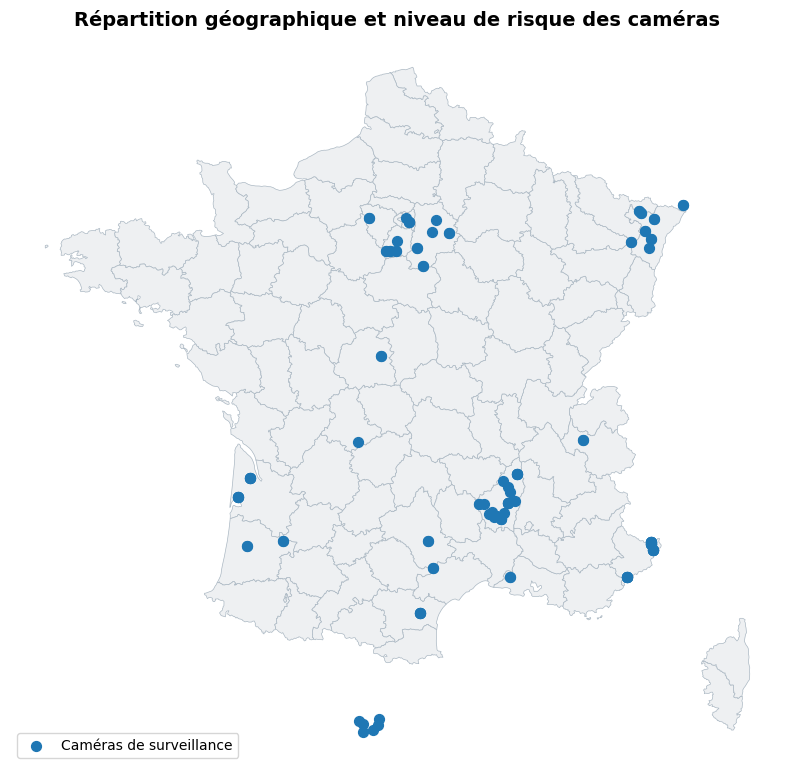

In [71]:
import matplotlib.pyplot as plt

# 2. Conversion en GeoDataFrame
geometrie = [Point(xy) for xy in zip(df_cameras['lon'], df_cameras['lat'])]
gdf_cameras = gpd.GeoDataFrame(df_cameras, geometry=geometrie, crs="EPSG:4326")

# 3. Chargement du fond de carte de la France (Départements)
url_contours_deps = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
gdf_departements = gpd.read_file(url_contours_deps)

# 4. Création du Plot avec Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

# On affiche d'abord le fond de carte des départements (en gris clair)
gdf_departements.plot(ax=ax, color='#eef0f2', edgecolor='#abb8c3', linewidth=0.5)

# On superpose les caméras (colorées en fonction de leur score FWI réel)
# 'cmap' permet d'avoir un dégradé de couleur automatique (du bleu au rouge pour le danger)
gdf_cameras.plot(
    ax=ax,
    markersize=50,
    label='Caméras de surveillance'
)

# Habillage du graphique
plt.title("Répartition géographique et niveau de risque des caméras", fontsize=14, fontweight='bold')
ax.set_axis_off() # Masque les axes de latitude/longitude pour que ce soit plus esthétique
plt.legend(loc='lower left')

# Sauvegarde de l'image
plt.savefig("repartition_geo_cameras.png", dpi=300, bbox_inches='tight')
plt.show()